In [86]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from typing import TypedDict, Annotated
from dotenv import load_dotenv
import requests
import os

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

In [87]:
load_dotenv()

llm = ChatNVIDIA(model = "nvidia/nemotron-3.5-lightning-30b-a3b")  # This model supports native tool calling in langchain

c:\Users\saura\OneDrive\Desktop\AI Engineering\LangGraph\myvenv\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:250: UserWarning: Found nvidia/nemotron-3.5-lightning-30b-a3b in available_models, but type is unknown and inference may fail.
  warnings.warn(


In [88]:
# Tools 
search_tool = DuckDuckGoSearchRun(region = 'us-en')

@tool
def calculator(first_num : float, second_num : float, operation : str) -> dict:
    """
    Perform a basic arithematic operation on two numbers,
    supported operations : add, sub, mul, div
    """
    
    try:
        if operation == 'add':
            result = first_num + second_num
        elif operation == 'sub':
            result = first_num - second_num
        elif operation == 'mul':
            result = first_num * second_num
        elif operation == 'div':
            if second_num == 0:
                return {'error':'Division by zero is not allowed!'}
            else:
                result = first_num / second_num
        else:
            return {'error':f'Unsupported operation: {operation}'}
        
        return {'first_num':first_num,'second_num':second_num,'operation':operation,'result':result}
        
    except Exception as e:
        return {'error':str(e)}
    
@tool
def get_stock_price(symbol : str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g, 'AAPL','TSLA')
    Using Alpha Vantage with api key in the url.
    """
    
    api_key = os.environ['STOCK_API_KEY']
    
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={api_key}"
    
    r = requests.get(url)
    return r.json()

In [89]:
# Make tools list
tools = [search_tool, calculator, get_stock_price]

# Make LLM tool aware
llm_with_tools = llm.bind_tools(tools)

c:\Users\saura\OneDrive\Desktop\AI Engineering\LangGraph\myvenv\Lib\site-packages\langchain_nvidia_ai_endpoints\chat_models.py:1044: UserWarning: Model 'nvidia/nemotron-3.5-lightning-30b-a3b' is not known to support tools. Your tool binding may fail at inference time.
  warnings.warn(


In [90]:
# Define State
class MessageState(TypedDict):  
    messages : Annotated[list[BaseMessage], add_messages]

In [91]:
# Define Chatbot function

# Chatnode function
def chat_node(state : MessageState):
    """LLM node that may answer a question or request a tool call."""
    messages = state['messages']
    
    response = llm_with_tools.invoke(messages)
    
    return {'messages':[response]}

# Toolnode function
tool_node = ToolNode(tools)   # Execute tool calls

In [ ]:
# Define Graph
graph = StateGraph(MessageState)

# Nodes & Edges
graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START,'chat_node')

# If LLM asks for a tool, go to tool_node, else finish
graph.add_conditional_edges('chat_node',tools_condition)

# Send back the tool response to the LLM to decide whether re-execution is needed or the final output is already acquired
graph.add_edge('tools','chat_node')


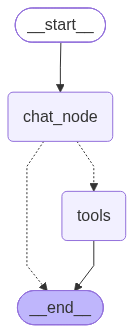

In [93]:
chatbot = graph.compile()

chatbot

In [94]:
# Regular Chat

out = chatbot.invoke({'messages':[HumanMessage(content = 'Hello')]})

print(out['messages'][-1].content)

Hello! How can I help you today?


In [97]:
# Chat Requiring tool

out = chatbot.invoke({'messages':[HumanMessage(content = 'What is 2*3?')]})

print(out['messages'][-1].content)

{"first_num": 2.0, "second_num": 3.0, "operation": "mul", "result": 6.0}


In [98]:
# Chat Requiring tool

out = chatbot.invoke({'messages':[HumanMessage(content = 'What is the stock price of apple?')]})

print(out['messages'][-1].content)

{"Global Quote": {"01. symbol": "AAPL", "02. open": "324.8700", "03. high": "330.8100", "04. low": "324.1100", "05. price": "328.2100", "06. volume": "37225838", "07. latest trading day": "2026-09-03", "08. previous close": "324.9600", "09. change": "3.2500", "10. change percent": "1.0001%"}}


In [ ]:
# Chat Requiring multiple tools

out = chatbot.invoke({'messages':[HumanMessage(content = 'What is the stock price of apple, how much will it cost me to buy 50 shares?')]})

print(out['messages'][-1].content)